In [1]:
import tensorflow.keras as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen=ImageDataGenerator(rescale=1./255)

In [4]:
train_generator=datagen.flow_from_directory('dataset1/training_set1',target_size=(64,64),class_mode='categorical')

Found 1200 images belonging to 3 classes.


In [5]:
test_generator=datagen.flow_from_directory('dataset1/test_set1',target_size=(64,64),class_mode='categorical')

Found 1200 images belonging to 3 classes.


In [6]:
train_generator

In [7]:
data,label=next(train_generator) ##generates 32 images their labels from out training data

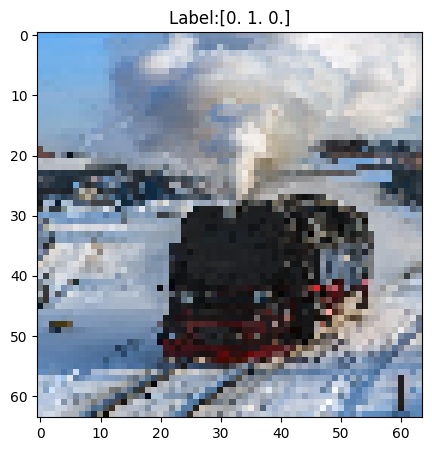

In [15]:
plt.figure(figsize=(5,5))
plt.imshow(data[2])  ##from 32 images take image
plt.title(f'Label:{label[3]}') ## take label of image ans show it as title of image
plt.show()

In [41]:
cnn=tf.models.Sequential()
cnn.add(tf.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64,64,3]))
cnn.add(tf.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.layers.Flatten())
cnn.add(tf.layers.Dense(units=128, activation='relu'))
cnn.add(tf.layers.Dense(units=3, activation='softmax')) #output layer


C:\Users\dhans\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [43]:

cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,475 (3.10 MB)

 Trainable params: 813,475 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
result=cnn.fit(x=train_generator, epochs=7)

Epoch 1/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step - accuracy: 0.5750 - loss: 0.8853
Epoch 2/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 328ms/step - accuracy: 0.7975 - loss: 0.5179
Epoch 3/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.8617 - loss: 0.3829
Epoch 4/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 307ms/step - accuracy: 0.9058 - loss: 0.2698
Epoch 5/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.9400 - loss: 0.1903
Epoch 6/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 308ms/step - accuracy: 0.9400 - loss: 0.1566
Epoch 7/7
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - accuracy: 0.9808 - loss: 0.0866


In [55]:
import numpy as np
from keras.utils import load_img, img_to_array

# Load image
new_image = load_img(
    r'C:\Users\dhans\OneDrive\Desktop\first bit\data science\dataset1\single_prediction1\test.jpg',
    target_size=(64, 64)
)

# Convert to array
new_image = img_to_array(new_image)

# Rescale if training used rescale=1./255
new_image = new_image / 255.0

# Add batch dimension
new_image = np.expand_dims(new_image, axis=0)

# Predict
result = cnn.predict(new_image)
print(result)

# Update labels to match your class order
class_labels = ['car', 'plane', 'train']

predicted_index = np.argmax(result)
prediction = class_labels[predicted_index]

print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
[[9.9193573e-01 2.4132985e-06 8.0619501e-03]]
Prediction: car
